# Goal Kick Progression Model

Same architecture as `goal_kick_model_standardized.ipynb` but targets
`sequence_progression_value` — our custom possession value metric inspired
by VAEP. Trained on the same 80% feature window; compared side-by-side
with the OBV model in the final cell.

OBV features (`obv_for_80`, `obv_against_80`) are removed from the input —
we are no longer relying on StatsBomb's proprietary OBV at all.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

PROJECT_ROOT = Path('../')
model_df = pd.read_parquet(PROJECT_ROOT / 'data' / 'feature_engineering' / 'model_features_80_20.parquet')
print(f'Loaded : {model_df.shape}')
print(f'Columns: {list(model_df.columns)}')

Loaded : (5113, 29)
Columns: ['goal_kick_id', 'obv_remaining', 'obv_for_80', 'obv_against_80', 'n_prog_passes_80', 'n_prog_carries_80', 'final_third_80', 'press_height_mean_x_80', 'press_height_max_x_80', 'def_line_depth_mean_x_80', 'avg_def_ball_dist_80', 'min_def_ball_dist_80', 'n_frames_pressure_80', 'press_fwd_speed_80', 'press_compactness_80', 'action_type', 'action_x', 'action_y', 'action_progressive', 'action_team_poss', 'period', 'possession_team_name', 'skc_match_id', 'sequence_progression_value', 'mean_action_prog_value', 'max_action_prog_value', 'n_prog_actions', 'prog_value_80', 'prog_value_20']


## Encode + define features

In [2]:
le = LabelEncoder()
model_df["action_type_enc"] = le.fit_transform(model_df["action_type"].fillna("Unknown"))

# Feature set: pressing/tracking features from the first 80% of the sequence,
# plus the progression value generated in that same 80% window.
FEATURE_COLS = [
    "n_prog_passes_80", "n_prog_carries_80", "final_third_80",
    "press_compactness_80", "press_height_mean_x_80", "press_height_max_x_80",
    "def_line_depth_mean_x_80", "avg_def_ball_dist_80", "min_def_ball_dist_80",
    "n_frames_pressure_80", "press_fwd_speed_80",
    "action_type_enc", "action_x", "action_y", "action_progressive",
    "action_team_poss",  # 1 = possession team action, 0 = defending team action
    "period",
    "prog_value_80",     # progression value generated in first 80% of sequence
]
# Target: progression value in the LAST 20% of the sequence only
TARGET_COL = "prog_value_20"

df_clean = model_df[FEATURE_COLS + [TARGET_COL]].dropna()
X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Target mean : {y.mean():.5f}  std : {y.std():.5f}")

Train : 4,068  |  Test : 1,018
Target mean : 0.00864  std : 0.02244


## Standardize features

Scaler fit on training set only to avoid data leakage.

In [3]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_all_s   = scaler.transform(X)

print('Feature means after scaling (should be ~0):')
print(pd.Series(X_train_s.mean(axis=0), index=FEATURE_COLS).round(4).to_string())

Feature means after scaling (should be ~0):
n_prog_passes_80            0.0
n_prog_carries_80          -0.0
final_third_80             -0.0
press_compactness_80       -0.0
press_height_mean_x_80     -0.0
press_height_max_x_80       0.0
def_line_depth_mean_x_80   -0.0
avg_def_ball_dist_80        0.0
min_def_ball_dist_80       -0.0
n_frames_pressure_80        0.0
press_fwd_speed_80          0.0
action_type_enc             0.0
action_x                   -0.0
action_y                    0.0
action_progressive          0.0
action_team_poss            0.0
period                      0.0
prog_value_80              -0.0


## Train models

In [4]:
models = {
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, max_depth=6,
                                                min_samples_leaf=10, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                    learning_rate=0.05, min_samples_leaf=10,
                                                    random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    cv_r2  = cross_val_score(model, X_all_s, y, cv=5, scoring='r2').mean()
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'CV_R2': cv_r2}
    print(f'{name:<25}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  CV_R2={cv_r2:.4f}')

best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_name]
print(f'\nBest model: {best_name}')

Ridge Regression           RMSE=0.0180  MAE=0.0100  R2=0.3445  CV_R2=0.3628


Random Forest              RMSE=0.0180  MAE=0.0089  R2=0.3489  CV_R2=0.3823


Gradient Boosting          RMSE=0.0181  MAE=0.0090  R2=0.3387  CV_R2=0.3789

Best model: Random Forest


## Feature importance (Ridge coefficients)

Standardized Ridge coefficients:
press_height_mean_x_80     -0.007838
press_height_max_x_80       0.005843
n_prog_carries_80           0.005277
n_prog_passes_80            0.004913
prog_value_80               0.003497
def_line_depth_mean_x_80    0.003366
action_x                    0.001279
period                      0.000747
min_def_ball_dist_80        0.000598
press_compactness_80        0.000552
avg_def_ball_dist_80        0.000336
press_fwd_speed_80         -0.000306
n_frames_pressure_80        0.000289
action_type_enc             0.000281
action_team_poss           -0.000205
final_third_80             -0.000178
action_progressive         -0.000176
action_y                    0.000048


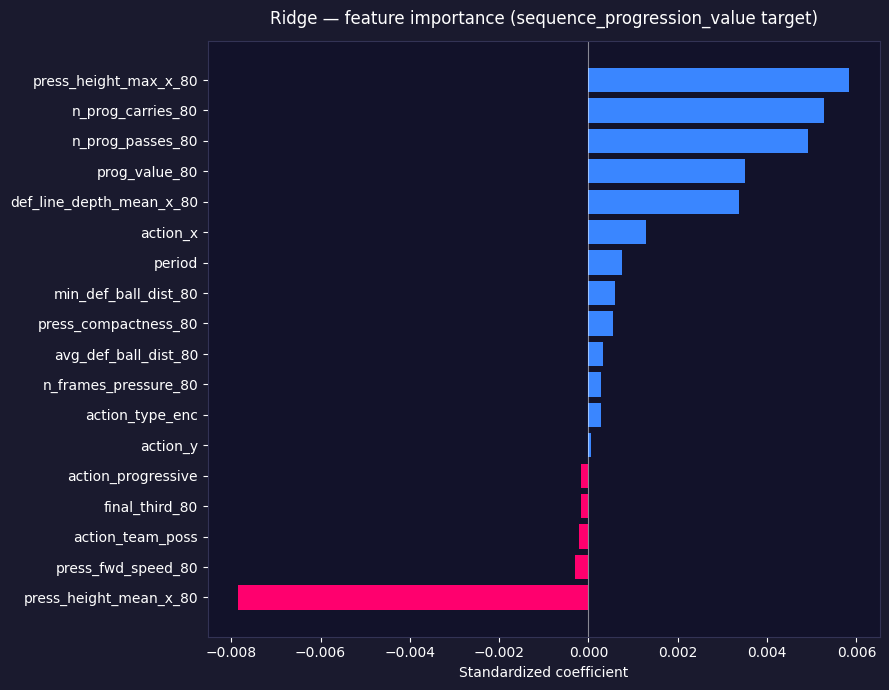

In [5]:
ridge = models['Ridge Regression']
coefs = pd.Series(ridge.coef_, index=FEATURE_COLS).sort_values(key=abs, ascending=False)

print('Standardized Ridge coefficients:')
print(coefs.round(6).to_string())

fig, ax = plt.subplots(figsize=(9, 7), facecolor='#1a1a2e')
ax.set_facecolor('#12122a')
sorted_coefs = coefs.sort_values()
colors = ['#3a86ff' if v > 0 else '#ff006e' for v in sorted_coefs]
ax.barh(sorted_coefs.index, sorted_coefs.values, color=colors)
ax.axvline(0, color='white', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Standardized coefficient', color='white')
ax.set_title('Ridge — feature importance (sequence_progression_value target)', color='white', pad=12)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')
plt.tight_layout()
plt.savefig('../model/feature_importance_progression.png', dpi=150, bbox_inches='tight')
plt.show()

## Actual vs Predicted

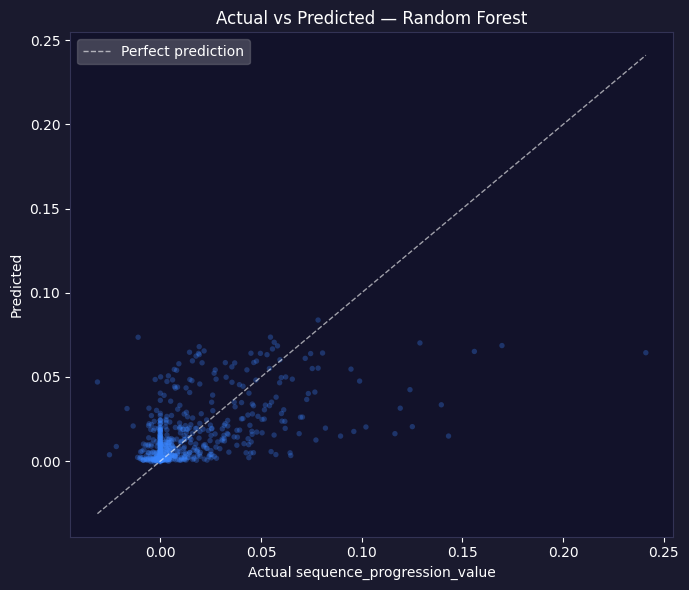

In [6]:
y_pred_test = best_model.predict(X_test_s)

fig, ax = plt.subplots(figsize=(7, 6), facecolor='#1a1a2e')
ax.set_facecolor('#12122a')
ax.scatter(y_test, y_pred_test, alpha=0.3, s=15, color='#3a86ff', edgecolors='none')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'w--', linewidth=1, alpha=0.6, label='Perfect prediction')
ax.set_xlabel('Actual sequence_progression_value', color='white')
ax.set_ylabel('Predicted', color='white')
ax.set_title(f'Actual vs Predicted — {best_name}', color='white')
ax.tick_params(colors='white')
ax.legend(framealpha=0.2, labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')
plt.tight_layout()
plt.savefig('../model/actual_vs_predicted_progression.png', dpi=150, bbox_inches='tight')
plt.show()

## Side-by-side comparison with OBV model

In [7]:
# OBV model results from goal_kick_model_standardized.ipynb
obv_results = {
    'Ridge Regression'  : {'RMSE': 0.0651, 'MAE': 0.0172, 'R2': 0.1771, 'CV_R2': 0.0347},
    'Random Forest'     : {'RMSE': 0.0690, 'MAE': 0.0166, 'R2': 0.0760, 'CV_R2': 0.0188},
    'Gradient Boosting' : {'RMSE': 0.0684, 'MAE': 0.0178, 'R2': 0.0914, 'CV_R2': 0.0174},
}

header = f'{"":<25}  {"OBV model":^40}  {"Progression model":^40}'
subhdr = f'{"Model":<25}  {"RMSE":>8} {"MAE":>8} {"R2":>8} {"CV_R2":>8}    {"RMSE":>8} {"MAE":>8} {"R2":>8} {"CV_R2":>8}'
print(header)
print(subhdr)
print('-' * 110)
for name in obv_results:
    o = obv_results[name]
    p = results.get(name, {})
    row = f'{name:<25}  {o["RMSE"]:>8.4f} {o["MAE"]:>8.4f} {o["R2"]:>8.4f} {o["CV_R2"]:>8.4f}    '
    if p:
        row += f'{p["RMSE"]:>8.4f} {p["MAE"]:>8.4f} {p["R2"]:>8.4f} {p["CV_R2"]:>8.4f}'
    print(row)

                                          OBV model                             Progression model            
Model                          RMSE      MAE       R2    CV_R2        RMSE      MAE       R2    CV_R2
--------------------------------------------------------------------------------------------------------------
Ridge Regression             0.0651   0.0172   0.1771   0.0347      0.0180   0.0100   0.3445   0.3628
Random Forest                0.0690   0.0166   0.0760   0.0188      0.0180   0.0089   0.3489   0.3823
Gradient Boosting            0.0684   0.0178   0.0914   0.0174      0.0181   0.0090   0.3387   0.3789


## Save model

In [8]:
with open('../model/best_model_progression.pkl', 'wb') as f:
    pickle.dump({
        'model'        : best_model,
        'scaler'       : scaler,
        'label_encoder': le,
        'feature_cols' : FEATURE_COLS,
        'model_name'   : best_name,
        'results'      : results,
    }, f)

print(f'Saved -> model/best_model_progression.pkl  ({best_name})')
print()
print('Final metrics:')
r = results[best_name]
print(f'  RMSE  : {r["RMSE"]:.4f}')
print(f'  MAE   : {r["MAE"]:.4f}')
print(f'  R2    : {r["R2"]:.4f}')
print(f'  CV R2 : {r["CV_R2"]:.4f}')

Saved -> model/best_model_progression.pkl  (Random Forest)

Final metrics:
  RMSE  : 0.0180
  MAE   : 0.0089
  R2    : 0.3489
  CV R2 : 0.3823
